# Reducing Customer Churn — A Retention Business Case

**Business question:** A telecom carrier loses about a quarter of its customers
each year. *Who is most likely to leave, why, and is it worth paying to keep
them?*

**Bottom line (TL;DR):**
- Churn is **26.5%** — roughly **$1.67M** of annual recurring revenue walking out the door.
- It's concentrated and predictable: month-to-month contracts, the first six
  months of tenure, fiber-optic internet, electronic-check payment, and no
  tech-support/security add-ons.
- A churn model (AUC **0.85**) puts **67% of all churn in the top 30% of customers by risk**.
- Targeting that group with a retention offer nets an estimated **~$347K/year at 2.7x ROI**.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

INK, BLUE, RED, MUT = "#1f2733", "#2563eb", "#dc2626", "#94a3b8"
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

df = pd.read_csv("data/telco_churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["churn"] = (df["Churn"] == "Yes").astype(int)
print(f"{len(df):,} customers, {df['churn'].mean():.1%} churn rate")

7,043 customers, 26.5% churn rate


## 1. How big is the problem?
Churn isn't just a rate — it's revenue. And the customers who leave pay *more* than the ones who stay, so this is expensive churn.

In [2]:
annual_at_risk = df.loc[df.churn == 1, "MonthlyCharges"].sum() * 12
print(f"Customers churned:        {df.churn.sum():,}")
print(f"Annual revenue at risk:   ${annual_at_risk:,.0f}")
print(f"Avg monthly bill — churned: ${df.loc[df.churn==1,'MonthlyCharges'].mean():.2f}")
print(f"Avg monthly bill — stayed:  ${df.loc[df.churn==0,'MonthlyCharges'].mean():.2f}")

Customers churned:        1,869
Annual revenue at risk:   $1,669,570
Avg monthly bill — churned: $74.44
Avg monthly bill — stayed:  $61.27


## 2. Who churns, and why?
The drivers are consistent and actionable — they point at contract structure, onboarding, and a few product gaps.

In [3]:
for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport"]:
    g = (df.groupby(col)["churn"].mean() * 100).round(1).sort_values(ascending=False)
    print(f"\nChurn by {col}:"); print(g.to_string())


Churn by Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

Churn by InternetService:
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4

Churn by PaymentMethod:
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2

Churn by TechSupport:
TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4


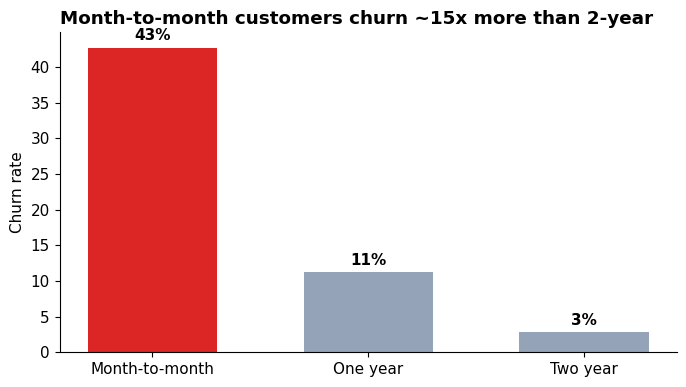

In [4]:
# Contract is the single biggest lever
fig, ax = plt.subplots(figsize=(7, 4))
order = ["Month-to-month", "One year", "Two year"]
vals = [df.loc[df.Contract == c, "churn"].mean() * 100 for c in order]
ax.bar(order, vals, color=[RED, MUT, MUT], width=0.6)
for i, v in enumerate(vals): ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
ax.set_title("Month-to-month customers churn ~15x more than 2-year", loc="left", fontweight="bold")
ax.set_ylabel("Churn rate"); plt.tight_layout(); plt.show()

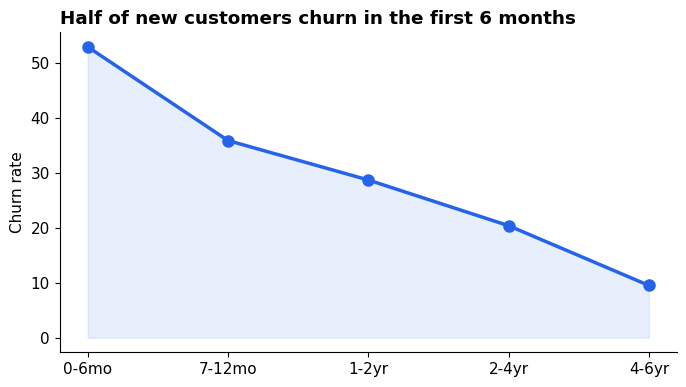

In [5]:
# Churn is front-loaded in the first months
df["tenure_bucket"] = pd.cut(df.tenure, [-1,6,12,24,48,72], labels=["0-6mo","7-12mo","1-2yr","2-4yr","4-6yr"])
curve = (df.groupby("tenure_bucket", observed=True)["churn"].mean()*100)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(curve.index.astype(str), curve.values, color=BLUE, marker="o", markersize=8, linewidth=2.5)
ax.fill_between(curve.index.astype(str), curve.values, color=BLUE, alpha=0.1)
ax.set_title("Half of new customers churn in the first 6 months", loc="left", fontweight="bold")
ax.set_ylabel("Churn rate"); plt.tight_layout(); plt.show()

## 3. Can we predict who's about to leave?
A logistic-regression model turns the drivers into a churn probability for every customer, so retention spend can be aimed instead of sprayed.

In [6]:
num = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
cat = ["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService",
       "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV",
       "StreamingMovies","Contract","PaperlessBilling","PaymentMethod"]
X, y = df[num + cat], df["churn"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

pre = ColumnTransformer([("n", StandardScaler(), num),
                         ("c", OneHotEncoder(handle_unknown="ignore"), cat)])
model = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))])
model.fit(Xtr, ytr)
auc = roc_auc_score(yte, model.predict_proba(Xte)[:, 1])
print(f"Test AUC: {auc:.3f}")

df["risk"] = model.predict_proba(X)[:, 1]
df["decile"] = pd.qcut(df["risk"], 10, labels=False) + 1

Test AUC: 0.846


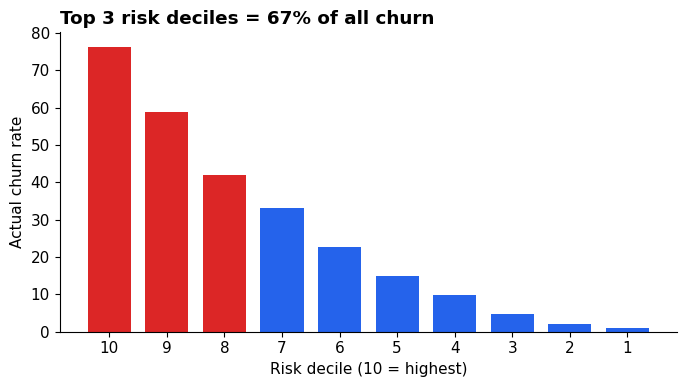

Top 30% of customers by risk contain 67% of all churners


In [7]:
# Lift: does the model actually concentrate churn?
dec = (df.groupby("decile")["churn"].mean()*100).round(1).sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
cols = [RED if d >= 8 else BLUE for d in dec.index]
ax.bar(dec.index.astype(str), dec.values, color=cols, width=0.75)
ax.set_title("Top 3 risk deciles = 67% of all churn", loc="left", fontweight="bold")
ax.set_xlabel("Risk decile (10 = highest)"); ax.set_ylabel("Actual churn rate")
plt.tight_layout(); plt.show()

capture = df.loc[df.decile >= 8, "churn"].sum() / df["churn"].sum()
print(f"Top 30% of customers by risk contain {capture:.0%} of all churners")

## 4. Is it worth paying to keep them?
The whole point. We target the top 30% risk with a retention offer and model the economics. Assumptions are explicit and conservative.

In [8]:
target = df[df.decile >= 8]
N = len(target)
annual_value = target["MonthlyCharges"].mean() * 12
expected_churners = target["risk"].sum()

OFFER_COST = 60      # $ per targeted customer (one-time incentive / discount value)
SAVE_RATE  = 0.30    # share of would-be churners the offer actually retains

saved = expected_churners * SAVE_RATE
saved_revenue = saved * annual_value
campaign_cost = N * OFFER_COST
net = saved_revenue - campaign_cost

print(f"Targeted customers:        {N:,}")
print(f"Expected churners:         {expected_churners:,.0f}")
print(f"Customers saved (30%):     {saved:,.0f}")
print(f"Saved annual revenue:      ${saved_revenue:,.0f}")
print(f"Campaign cost (@$60 ea):   ${campaign_cost:,.0f}")
print(f"Net benefit:               ${net:,.0f}")
print(f"ROI:                       {net/campaign_cost:.1f}x")

Targeted customers:        2,113
Expected churners:         1,670
Customers saved (30%):     501
Saved annual revenue:      $473,679
Campaign cost (@$60 ea):   $126,780
Net benefit:               $346,899
ROI:                       2.7x


In [9]:
# Sensitivity: still positive across a wide range of save rates
rows = []
for sr in [0.15, 0.20, 0.30, 0.40]:
    sv = expected_churners * sr * annual_value
    rows.append({"save_rate": f"{sr:.0%}", "net_benefit": sv - campaign_cost,
                 "roi": (sv - campaign_cost)/campaign_cost})
sens = pd.DataFrame(rows)
sens["net_benefit"] = sens["net_benefit"].map(lambda v: f"${v:,.0f}")
sens["roi"] = sens["roi"].map(lambda v: f"{v:.1f}x")
print(sens.to_string(index=False))

save_rate net_benefit  roi
      15%    $110,059 0.9x
      20%    $189,006 1.5x
      30%    $346,899 2.7x
      40%    $504,791 4.0x


## Recommendation

1. **Aim, don't spray.** Run retention against the model's **top 30% risk** — it
   holds two-thirds of all churn, so the same budget works ~2x harder.
2. **Attack the #1 lever — contract type.** Offer high-risk *month-to-month*
   customers an incentive to move to a 1- or 2-year term (month-to-month churns
   ~43% vs ~3% on two-year).
3. **Fix the first six months.** Half of new customers leave early — invest in
   onboarding, proactive check-ins, and bundling **tech support / online
   security**, both of which cut churn roughly in half.
4. **Nudge electronic-check payers to autopay**, the highest-churn payment method.

**Expected impact:** ~**$347K net/year at 2.7x ROI**, and positive even at a
conservative 15% save rate.

**Caveats & next steps:** the save-rate assumption should be validated with a
small **A/B holdout** before scaling; add customer-service and usage data to
sharpen the model; revisit fiber-optic experience, which carries elevated churn
even after controlling for price.